# Training Curves — All Attributes (new vs. old checkpoints)

Variant of [`vis_training_curves_all_attributes.dedup.ipynb`](vis_training_curves_all_attributes.dedup.ipynb)
that overlays two probe-checkpoint generations on the same axes instead of
plotting one:

- **new** — `../probe_checkpoints` (llama2 + Claude Opus samples + `sol_100`)
- **old** — `../probe_checkpoints.withLLaMaDuplicates`, the checkpoint
  directory `dedup.ipynb` originally plotted

Same reader as `dedup.ipynb`: `*_history.pkl` files written by
[`train_control_probe.py`](../src/train_control_probe.py) /
[`train_reading_probe.py`](../src/train_reading_probe.py) via
`probe_common.train_attribute`, each holding a `history_by_layer[layer]`
dict of `train_loss` / `test_loss` / `train_acc` / `test_acc` lists (one
entry per epoch) plus the `best_layer` picked by best test accuracy.

New-generation curves are drawn solid/opaque; old-generation curves are
drawn faded, in the same per-attribute color, so the shift between runs is
visible directly on top of the old curves rather than in a separate figure.

In [1]:
import glob
import os
import pickle

import matplotlib.pyplot as plt

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

NEW_CHECKPOINT_DIR = "../probe_checkpoints"
OLD_CHECKPOINT_DIR = "../probe_checkpoints.withLLaMaDuplicates"

# Fixed attribute -> color order (data-viz categorical palette, slots 1-4),
# so an attribute keeps the same color across every figure/notebook run.
ATTRIBUTE_COLORS = {
    "gullibility": "#2a78d6",       # blue
    "rationality": "#eb6834",       # orange
    "seriousness": "#1baf7a",       # aqua
    "certainty_seeking": "#eda100",  # yellow
}

# Old-generation curves are drawn faded behind full-opacity new-generation
# curves, in the same attribute color, so both runs read as one overlay.
ALPHA_NEW = 1.0
ALPHA_OLD = 0.35

## Discover available (probe_type, dataset_tag) runs, new and old

In [2]:
def discover_runs(checkpoint_dir):
    """Yield (probe_type, dataset_tag, {attribute: history_dict}) for every
    dataset-tag directory found under each probe_type/, using whichever
    attributes have a *_history.pkl there."""
    for probe_type in sorted(os.listdir(checkpoint_dir)):
        probe_dir = os.path.join(checkpoint_dir, probe_type)
        if not os.path.isdir(probe_dir):
            continue
        for dataset_tag in sorted(os.listdir(probe_dir)):
            tag_dir = os.path.join(probe_dir, dataset_tag)
            history_paths = sorted(glob.glob(os.path.join(tag_dir, "*_history.pkl")))
            if not history_paths:
                continue
            histories = {}
            for path in history_paths:
                attribute = os.path.basename(path).replace("_history.pkl", "")
                with open(path, "rb") as f:
                    histories[attribute] = pickle.load(f)
            yield probe_type, dataset_tag, histories


# One dataset_tag per probe_type is expected in each checkpoint dir, so keep
# a simple probe_type -> (dataset_tag, histories) map for each generation.
new_runs = {probe_type: (dataset_tag, histories)
            for probe_type, dataset_tag, histories in discover_runs(NEW_CHECKPOINT_DIR)}
old_runs = {probe_type: (dataset_tag, histories)
            for probe_type, dataset_tag, histories in discover_runs(OLD_CHECKPOINT_DIR)}

probe_types = sorted(set(new_runs) | set(old_runs))
for probe_type in probe_types:
    new_tag, new_histories = new_runs.get(probe_type, (None, {}))
    old_tag, old_histories = old_runs.get(probe_type, (None, {}))
    print(f"{probe_type}:")
    print(f"  new [{new_tag}]: {', '.join(sorted(new_histories)) or '(none)'}")
    print(f"  old [{old_tag}]: {', '.join(sorted(old_histories)) or '(none)'}")

control_probe:
  new [llama2_sample2+claudeopus_sample2+sol_100]: certainty_seeking, gullibility, rationality, seriousness
  old [llama2+claudeopus_sample2]: certainty_seeking, gullibility, rationality, seriousness
reading_probe:
  new [llama2_sample2+claudeopus_sample2+sol_100]: certainty_seeking, gullibility, rationality, seriousness
  old [llama2+claudeopus_sample2]: certainty_seeking, gullibility, rationality, seriousness


## Plot: all attributes' loss + accuracy curves, per probe type (new over old)

saved ../probe_checkpoints/control_probe/llama2_sample2+claudeopus_sample2+sol_100/plots/all_attributes_training_curves_vs_old.png


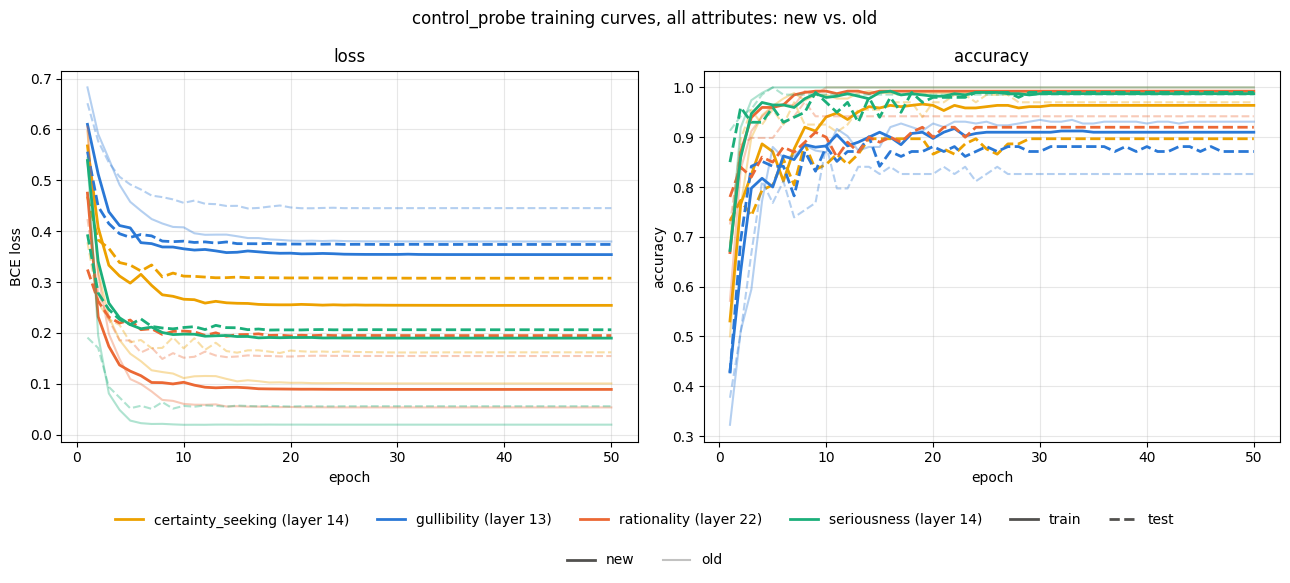

saved ../probe_checkpoints/reading_probe/llama2_sample2+claudeopus_sample2+sol_100/plots/all_attributes_training_curves_vs_old.png


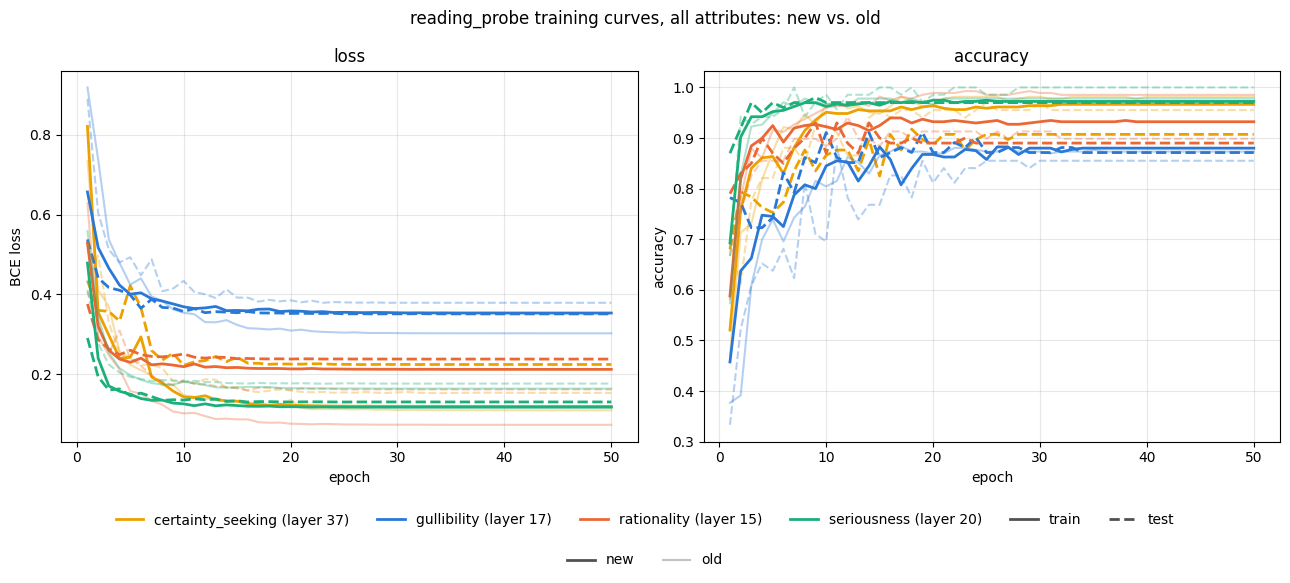

In [3]:
def plot_all_attributes(probe_type, new_tag, new_histories, old_tag, old_histories, out_path=None):
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 5))

    attributes = sorted(set(new_histories) | set(old_histories))
    for attribute in attributes:
        color = ATTRIBUTE_COLORS.get(attribute, "#898781")

        for histories, alpha, linewidth in ((old_histories, ALPHA_OLD, 1.5), (new_histories, ALPHA_NEW, 2)):
            history = histories.get(attribute)
            if history is None:
                continue
            best_layer = history["best_layer"]
            curves = history["history_by_layer"][best_layer]
            epochs = range(1, len(curves["train_loss"]) + 1)
            label = f"{attribute} (layer {best_layer})" if histories is new_histories else None

            ax_loss.plot(epochs, curves["train_loss"], color=color, linestyle="-", linewidth=linewidth, alpha=alpha)
            ax_loss.plot(epochs, curves["test_loss"], color=color, linestyle="--", linewidth=linewidth, alpha=alpha)

            ax_acc.plot(epochs, curves["train_acc"], color=color, linestyle="-", linewidth=linewidth, alpha=alpha, label=label)
            ax_acc.plot(epochs, curves["test_acc"], color=color, linestyle="--", linewidth=linewidth, alpha=alpha)

    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("BCE loss")
    ax_loss.set_title("loss")
    ax_loss.grid(alpha=0.3)

    ax_acc.set_xlabel("epoch")
    ax_acc.set_ylabel("accuracy")
    ax_acc.set_title("accuracy")
    ax_acc.grid(alpha=0.3)

    # Three legend rows: attribute color (from ax_acc's labeled new-gen
    # lines), solid/dashed key shared by both panels, then the new/old
    # generation key (opacity), each added as its own fig-level legend so
    # matplotlib doesn't drop the earlier ones.
    attr_handles, attr_labels = ax_acc.get_legend_handles_labels()
    split_handles = [
        plt.Line2D([0], [0], color="#52514e", linestyle="-", linewidth=2),
        plt.Line2D([0], [0], color="#52514e", linestyle="--", linewidth=2),
    ]
    split_labels = ["train", "test"]
    gen_handles = [
        plt.Line2D([0], [0], color="#52514e", linewidth=2, alpha=ALPHA_NEW),
        plt.Line2D([0], [0], color="#52514e", linewidth=1.5, alpha=ALPHA_OLD),
    ]
    gen_labels = ["new", "old"]

    fig.legend(
        attr_handles + split_handles, attr_labels + split_labels,
        loc="lower center", bbox_to_anchor=(0.5, -0.08),
        ncol=len(attr_handles) + 2, frameon=False,
    )
    fig.legend(
        gen_handles, gen_labels,
        loc="lower center", bbox_to_anchor=(0.5, -0.16),
        ncol=2, frameon=False,
    )

    fig.suptitle(f"{probe_type} training curves, all attributes: new vs. old")
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()


for probe_type in probe_types:
    new_tag, new_histories = new_runs.get(probe_type, (None, {}))
    old_tag, old_histories = old_runs.get(probe_type, (None, {}))
    out_path = os.path.join(
        NEW_CHECKPOINT_DIR, probe_type, new_tag or old_tag, "plots",
        "all_attributes_training_curves_vs_old.png",
    )
    plot_all_attributes(probe_type, new_tag, new_histories, old_tag, old_histories, out_path=out_path)

## Plot: accuracy vs. layer, all attributes (new over old)

Same `best_acc_per_layer` / `final_acc_per_layer` overlay as `dedup.ipynb`,
now drawn twice per attribute — faded for the old checkpoint generation,
full-opacity for the new one — so a layer-wise shift between runs shows up
directly, including whether the chosen `best_layer` (starred) moved.

saved ../probe_checkpoints/control_probe/llama2_sample2+claudeopus_sample2+sol_100/plots/all_attributes_accuracy_vs_layer_vs_old.png


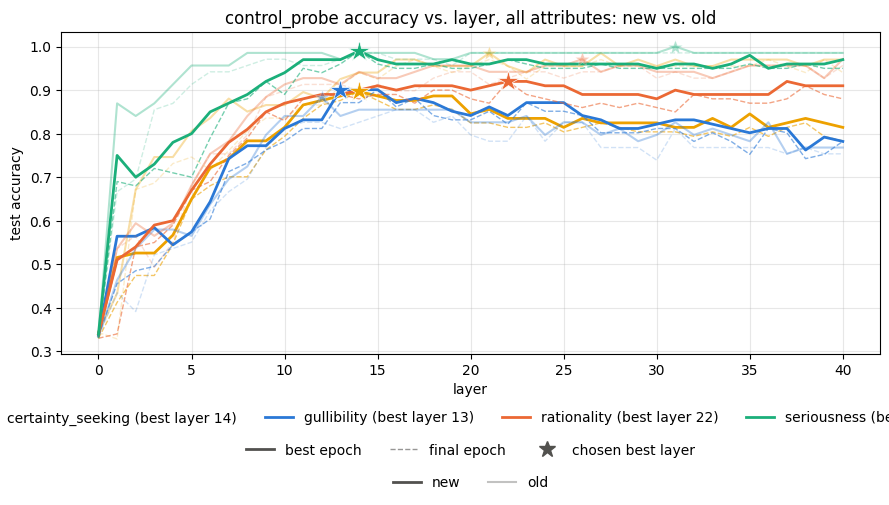

saved ../probe_checkpoints/reading_probe/llama2_sample2+claudeopus_sample2+sol_100/plots/all_attributes_accuracy_vs_layer_vs_old.png


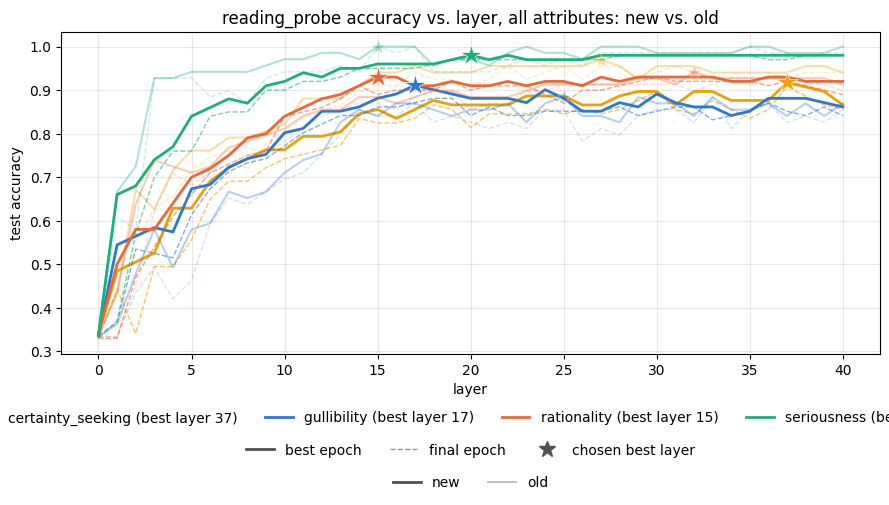

In [4]:
def plot_accuracy_vs_layer_all_attributes(probe_type, new_tag, new_histories, old_tag, old_histories, out_path=None):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    attributes = sorted(set(new_histories) | set(old_histories))
    for attribute in attributes:
        color = ATTRIBUTE_COLORS.get(attribute, "#898781")

        for histories, alpha, linewidth in ((old_histories, ALPHA_OLD, 1.5), (new_histories, ALPHA_NEW, 2)):
            history = histories.get(attribute)
            if history is None:
                continue
            layers = sorted(history["best_acc_per_layer"].keys())
            best_acc = [history["best_acc_per_layer"][l] for l in layers]
            final_acc = [history["final_acc_per_layer"][l] for l in layers]
            best_layer = history["best_layer"]
            label = f"{attribute} (best layer {best_layer})" if histories is new_histories else None

            ax.plot(layers, best_acc, color=color, linestyle="-", linewidth=linewidth, alpha=alpha, label=label)
            ax.plot(layers, final_acc, color=color, linestyle="--", linewidth=max(linewidth - 1, 1), alpha=alpha * 0.6)
            ax.plot(best_layer, history["best_acc_per_layer"][best_layer],
                    marker="*", markersize=16 if alpha == ALPHA_NEW else 10, color=color,
                    markeredgecolor="white", markeredgewidth=0.5, alpha=alpha, linestyle="none", zorder=5)

    ax.set_xlabel("layer")
    ax.set_ylabel("test accuracy")
    ax.grid(alpha=0.3)

    # Three stacked single-purpose legends -- attribute colors, line/marker
    # key, then new/old generation (opacity) key -- rather than one
    # multi-column legend, which would interleave the groups column-major.
    attr_handles, attr_labels = ax.get_legend_handles_labels()
    split_handles = [
        plt.Line2D([0], [0], color="#52514e", linestyle="-", linewidth=2),
        plt.Line2D([0], [0], color="#52514e", linestyle="--", linewidth=1, alpha=0.6),
        plt.Line2D([0], [0], color="#52514e", marker="*", markersize=12, linestyle="none"),
    ]
    split_labels = ["best epoch", "final epoch", "chosen best layer"]
    gen_handles = [
        plt.Line2D([0], [0], color="#52514e", linewidth=2, alpha=ALPHA_NEW),
        plt.Line2D([0], [0], color="#52514e", linewidth=1.5, alpha=ALPHA_OLD),
    ]
    gen_labels = ["new", "old"]

    attr_legend = ax.legend(
        attr_handles, attr_labels, loc="upper center", bbox_to_anchor=(0.5, -0.14),
        ncol=len(attr_handles), frameon=False,
    )
    ax.add_artist(attr_legend)
    split_legend = ax.legend(
        split_handles, split_labels, loc="upper center", bbox_to_anchor=(0.5, -0.24),
        ncol=len(split_handles), frameon=False,
    )
    ax.add_artist(split_legend)
    gen_legend = ax.legend(
        gen_handles, gen_labels, loc="upper center", bbox_to_anchor=(0.5, -0.34),
        ncol=2, frameon=False,
    )

    ax.set_title(f"{probe_type} accuracy vs. layer, all attributes: new vs. old")
    fig.tight_layout()
    if out_path:
        # bbox_extra_artists: the stacked legends live outside the axes
        # bbox (via bbox_to_anchor), so bbox_inches="tight" needs them
        # listed explicitly or the saved crop clips the later ones.
        fig.savefig(out_path, dpi=150, bbox_inches="tight",
                    bbox_extra_artists=(attr_legend, split_legend, gen_legend))
        print(f"saved {out_path}")
    plt.show()


for probe_type in probe_types:
    new_tag, new_histories = new_runs.get(probe_type, (None, {}))
    old_tag, old_histories = old_runs.get(probe_type, (None, {}))
    out_path = os.path.join(
        NEW_CHECKPOINT_DIR, probe_type, new_tag or old_tag, "plots",
        "all_attributes_accuracy_vs_layer_vs_old.png",
    )
    plot_accuracy_vs_layer_all_attributes(probe_type, new_tag, new_histories, old_tag, old_histories, out_path=out_path)